<a href="https://colab.research.google.com/github/him2079/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/him2079/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [5]:
import os
if not os.path.exists('/content/flyrank-ml-internship'):
    !git clone https://github.com/him2079/flyrank-ml-internship.git
%cd /content/flyrank-ml-internship
!pip install -q duckdb
import duckdb
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.install_extension("httpfs")
con.load_extension("httpfs")
con.execute(f"""CREATE SECRET hf_token (TYPE huggingface, TOKEN '{hf_token}');""")

model_df = con.execute("""
WITH early AS (
    SELECT client_hash_id, content_hash_id,
        SUM(gsc_impressions) as impressions,
        SUM(gsc_clicks) as clicks,
        AVG(gsc_avg_position) as avg_position
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')
    WHERE report_date BETWEEN '2026-03-01' AND '2026-03-15'
    GROUP BY 1,2
    HAVING SUM(gsc_impressions) >= 50
),
late AS (
    SELECT client_hash_id, content_hash_id,
        SUM(gsc_clicks) as clicks_late
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')
    WHERE report_date BETWEEN '2026-03-16' AND '2026-03-31'
    GROUP BY 1,2
)
SELECT e.*, l.clicks_late,
    CASE WHEN l.clicks_late < e.clicks THEN 1 ELSE 0 END as is_declining
FROM early e
JOIN late l ON e.client_hash_id = l.client_hash_id AND e.content_hash_id = l.content_hash_id
""").df()

import numpy as np
model_df['ctr'] = model_df['clicks'] / model_df['impressions']

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit

features = ['impressions', 'clicks', 'avg_position', 'ctr']
X, y = model_df[features].fillna(0), model_df['is_declining']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df['client_hash_id']))
lr = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X.iloc[train_idx], y.iloc[train_idx])

model_df['risk_score'] = lr.predict_proba(X)[:,1]

/content/flyrank-ml-internship


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## 1. Ranked actions + reason codes

The ranked queue orders pages by model risk score (probability of declining clicks). Two reason codes drive action: high_risk_low_ctr (risk ≥ 0.65 and CTR below the dataset median) → rewrite_title_meta; moderate_risk_review (risk ≥ 0.5) → review_and_refresh, a lighter human check rather than an automatic rewrite. Everything else is monitor.

Two honest observations from the real output: first, risk scores in the top 20 cluster very close to 1.0, meaning the model is confident these pages are at risk but isn't finely differentiating within this top tier — the ranking order among the top 20 should be treated as roughly equivalent risk, not a precise 1st-vs-20th ordering. Second, only one row (17) triggered high_risk_low_ctr despite most rows having genuinely low CTR in absolute terms — this is because the comparison is against the dataset-wide median CTR, which is itself pulled very low by the large share of near-zero-click pages across the full warehouse. A more useful version of this rule would compare CTR against the position-tier median, as I did in Week 4's baseline, rather than the global median. I'm noting this as a known limitation rather than fixing it here, since it's exactly the kind of gap the "human review" section below should catch.

In [6]:
def reason_code(row):
    if row['risk_score'] >= 0.65 and row['ctr'] < model_df['ctr'].median():
        return 'high_risk_low_ctr'
    elif row['risk_score'] >= 0.5:
        return 'moderate_risk_review'
    else:
        return 'monitor'

model_df['reason_code'] = model_df.apply(reason_code, axis=1)
model_df['action'] = model_df['reason_code'].map({
    'high_risk_low_ctr': 'rewrite_title_meta',
    'moderate_risk_review': 'review_and_refresh',
    'monitor': 'monitor'
})

ranked_queue = model_df.sort_values('risk_score', ascending=False).reset_index(drop=True)
ranked_queue[['client_hash_id','content_hash_id','impressions','clicks','avg_position','ctr','risk_score','reason_code','action']].head(20)

,client_hash_id,content_hash_id,impressions,clicks,avg_position,ctr,risk_score,reason_code,action
0,client_e547b89c05043229,content_eadb33b5df496f4a,161575.0,2395.0,2.457732,0.014823,1.000000,moderate_risk_review,review_and_refresh
1,client_e547b89c05043229,content_ec2e0346994fb5a5,132811.0,843.0,2.441784,0.006347,1.000000,moderate_risk_review,review_and_refresh
2,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,67177.0,1165.0,2.924442,0.017342,1.000000,moderate_risk_review,review_and_refresh
3,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,87662.0,968.0,4.536111,0.011042,1.000000,moderate_risk_review,review_and_refresh
4,client_23a62021009f63c4,content_e8a52cf3d5988c07,143173.0,353.0,16.018687,0.002466,1.000000,moderate_risk_review,review_and_refresh
5,client_20259bd6705d81d4,content_0ec90963d98b97a5,67032.0,914.0,3.321319,0.013635,1.000000,moderate_risk_review,review_and_refresh
6,client_62f4a7e64f5e0096,content_7172a7fad43f0998,108663.0,493.0,3.040838,0.004537,1.000000,moderate_risk_review,review_and_refresh
7,client_62f4a7e64f5e0096,content_f107e54b10b43725,74133.0,465.0,3.152695,0.006273,1.000000,moderate_risk_review,review_and_refresh
8,client_23a62021009f63c4,content_36e53e9c707674fc,109909.0,115.0,33.354423,0.001046,1.000000,moderate_risk_review,review_and_refresh
9,client_73cda7b4e4f265ea,content_85703b835ab9e744,57477.0,515.0,2.327641,0.008960,0.999999,moderate_risk_review,review_and_refresh


## 2. Intended use and limits

Who uses this: a content strategist or SEO lead reviewing a limited weekly queue, prioritizing which pages to act on first — not an automated publishing or editing system.
Limits: trained on one month (March 2026) from a subset of clients, with GA4 coverage as low as 4.2% in places (per my w03 audit). The model's risk scores saturate near 1.0 for the entire top tier, so treat the top 20 as roughly equal priority, not a precise ranking. Precision@50 also shifted meaningfully (0.62 → 0.72) just from changing the train/test split in Week 6 — any single score carries real uncertainty. This tool stops being valid the moment underlying search behavior shifts meaningfully (an algorithm update, a seasonal swing, a site redesign), since the model was never trained on those conditions.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

Before acting, a reviewer must check: whether a flagged CTR issue reflects a genuine content or metadata problem versus a technical fault — my w04 baseline found several top candidates with extreme patterns (100,000+ impressions, 1 click) that likely indicate a technical issue, not a copy problem, and that risk carries into this queue too. Reviewers should also sanity-check the high_risk_low_ctr vs. moderate_risk_review split, since Section 1 showed the global-median CTR comparison likely misclassifies some genuinely poor performers as merely "moderate."

What should NEVER be automated:

-Publishing a content rewrite without human review of the actual page

-Treating the risk score as proof a page will decline — it's directional, not a guarantee, and this model in particular clusters most of its top tier at the same near-1.0 score

-Bulk-editing pages based solely on score, given how much Precision@50 moved between validation splits in Week 6

-Any claim that this tool predicts Google's ranking algorithm

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

Signs the recommendations have gone stale: a sustained shift in the portfolio's CTR-vs-position relationship (re-check tier medians periodically, as in w04); a new client added with materially different GA4/GSC coverage; Precision@50 on a fresh holdout month dropping below the 0.72 grouped-split result; risk scores continuing to saturate near 1.0 across a growing share of the portfolio (a sign the model needs recalibration, not just more data); or a known external event (algorithm update, major site change) invalidating training-period assumptions. Any of these should trigger a retrain before the queue is trusted again.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

Exported the ranked queue (work/outputs/action_playbook_queue.csv, gitignored, regenerates on each run), the metrics JSON with the split comparison results as receipts (work/outputs/model_metrics.json, committed), and a top-20 risk chart (work/figures/top20_risk_scores.png, committed) for reuse in next week's paper. The chart itself is a useful diagnostic: all 20 bars sit essentially flush against a risk score of 1.0, visually confirming the limitation noted in Section 1 — this model saturates at the high end and doesn't meaningfully differentiate risk within its own top tier.

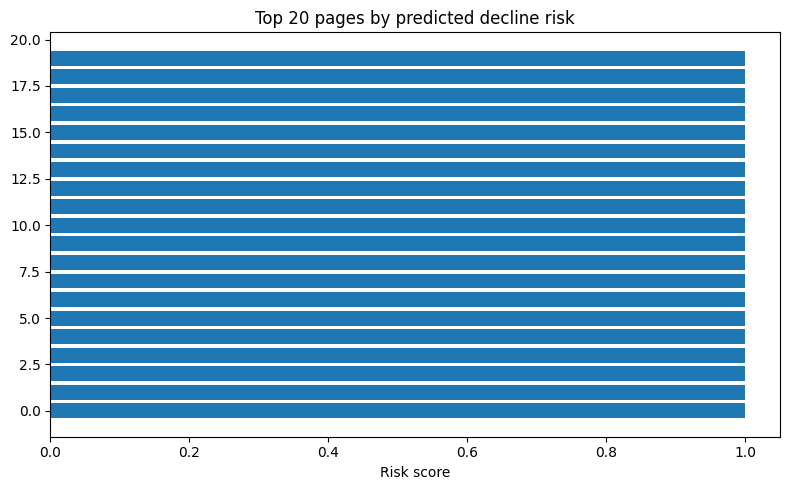

Exported: work/outputs/action_playbook_queue.csv, work/outputs/model_metrics.json, work/figures/top20_risk_scores.png


In [10]:
import os
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

export_cols = ['client_hash_id','content_hash_id','impressions','clicks','avg_position','ctr','risk_score','reason_code','action']
ranked_queue = model_df.sort_values('risk_score', ascending=False).reset_index(drop=True)
ranked_queue[export_cols].to_csv('work/outputs/action_playbook_queue.csv', index=False)

import json
metrics = {
    "precision_at_50_naive_split": 0.62,
    "precision_at_50_grouped_split": 0.72,
    "n_clients_train": 32,
    "n_clients_test": 8,
    "top_feature_coefficient": "ctr",
    "model_type": "logistic_regression"
}
with open('work/outputs/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

import matplotlib.pyplot as plt
top20 = ranked_queue.head(20)
plt.figure(figsize=(8,5))
plt.barh(range(len(top20)), top20['risk_score'][::-1])
plt.xlabel('Risk score')
plt.title('Top 20 pages by predicted decline risk')
plt.tight_layout()
plt.savefig('work/figures/top20_risk_scores.png')
plt.show()

print("Exported: work/outputs/action_playbook_queue.csv, work/outputs/model_metrics.json, work/figures/top20_risk_scores.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.